In [1]:
import gcinfo
import pandas as pd

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Immigrants to Canada, by country of last permanent residence"')["results"][0])


=== Immigrants to Canada, by country of last permanent residence ===
ID: fc6ad2eb-51f8-467c-be01-c4bda5b6186b
Org: Statistics Canada | Statistique Canada
Notes: <p>This table contains 25 series, with data for years 1955 - 2013 (not all combinations necessarily have data for all years). This table contains data described by the following dimensions (Not all co...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710001001
Citation: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence
DOI:      https://doi.org/10.25318/1710001001-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100010-SDMX.zip


In [2]:
df_origin, df_origin_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip")

Using cached file: cache\17100010-eng.zip


In [3]:
pd.Series(df_origin[["Last permanent residence"]].values.flatten()).unique()

array(['Total immigrants', 'Total Europe', 'Great Britain', 'France',
       'Germany', 'Netherlands', 'Greece', 'Italy', 'Portugal',
       'Other Europe', 'Total Asia', 'Australasia',
       'Total United States, West Indies', 'United States', 'West Indies',
       'All other countries', 'Poland', 'India', 'Hong Kong', 'Vietnam',
       'Philippines', 'Other Asia', 'Africa',
       'Other North and Central America', 'South America'], dtype=object)

In [4]:
df_origin_meta

# These regions should add up to `Total immigrants`
main_regions = [
    "Total Europe",
    "Total Asia",
    "Australasia",
    "Total United States, West Indies",
    "Africa",
    "Other North and Central America",
    "South America",
    "All other countries",
]

In [5]:
df_origin_1955 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "1955"]
df_origin_1955.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [6]:
df_origin_2013 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "2013"]
df_origin_2013.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
4828,2013-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,58246,NaN,NaN,NaN,0
4829,2013-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,7648,NaN,NaN,NaN,0
4830,2013-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,1382,NaN,NaN,NaN,0
4831,2013-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,1779,NaN,NaN,NaN,0
4832,2013-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,251,NaN,NaN,NaN,0


In [7]:
print(df_origin_1955.shape)
df_origin_1955.head()

(64, 15)


,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [8]:
df_origin_1955_main_regions = df_origin_1955[df_origin_1955["Last permanent residence"].isin(main_regions)]
print(df_origin_1955_main_regions.shape)
df_origin_1955_main_regions_summed = (
    df_origin_1955_main_regions
    .assign(YEAR=df_origin_1955_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_1955_main_regions_summed

(20, 15)


,YEAR,Last permanent residence,VALUE
0,1955,All other countries,2625
1,1955,Australasia,1700
2,1955,Total Asia,3662
3,1955,Total Europe,90771
4,1955,"Total United States, West Indies",11188


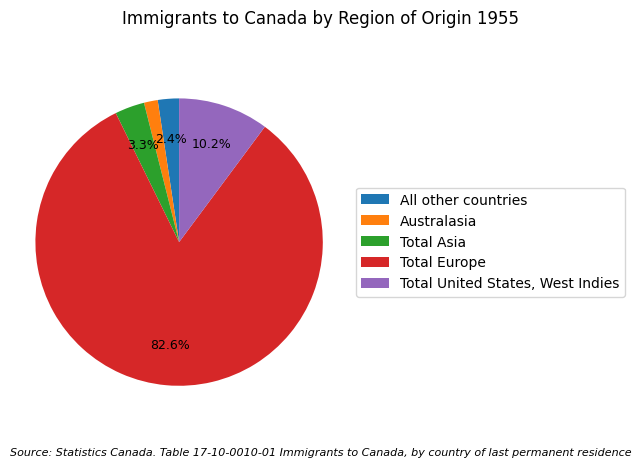

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Last permanent residence": [
        "All other countries",
        "Australasia",
        "Total Asia",
        "Total Europe",
        "Total United States, West Indies"
    ],
    "VALUE": [2625, 1700, 3662, 90771, 11188]
}
df = pd.DataFrame(data)

fig, ax = plt.subplots()

def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 2 else ""

wedges, texts, autotexts = ax.pie(
    df["VALUE"],
    labels=None,
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.72,
    radius=1.1
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

ax.legend(
    wedges,
    df["Last permanent residence"],
    title=None,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True
)

fig.suptitle("Immigrants to Canada by Region of Origin 1955", y=0.95)

plt.figtext(
    0.5, 0.02,
    "Source: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(right=0.68, bottom=0.12, top=0.88)
plt.tight_layout()
plt.show()

In [10]:
df_origin_2013_main_regions = df_origin_2013[df_origin_2013["Last permanent residence"].isin(main_regions)]
print(df_origin_2013_main_regions.shape)
df_origin_2013_main_regions_summed = (
    df_origin_2013_main_regions
    .assign(YEAR=df_origin_2013_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_2013_main_regions_summed

(16, 15)


,YEAR,Last permanent residence,VALUE
0,2013,Africa,17527
1,2013,All other countries,324
2,2013,Australasia,816
3,2013,Other North and Central America,2590
4,2013,South America,4613
5,2013,Total Asia,80438
6,2013,Total Europe,16883
7,2013,"Total United States, West Indies",10495


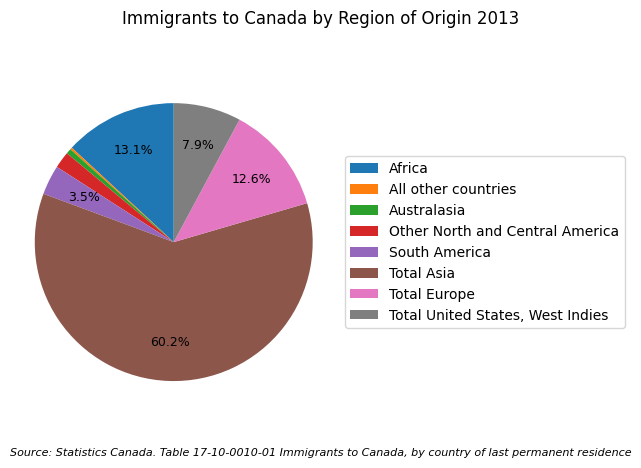

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Last permanent residence": [
        "Africa",
        "All other countries",
        "Australasia",
        "Other North and Central America",
        "South America",
        "Total Asia",
        "Total Europe",
        "Total United States, West Indies"
    ],
    "VALUE": [17527, 324, 816, 2590, 4613, 80438, 16883, 10495]
}
df = pd.DataFrame(data)

fig, ax = plt.subplots()

def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 2 else ""

wedges, texts, autotexts = ax.pie(
    df["VALUE"],
    labels=None,
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.72,
    radius=1.1
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

ax.legend(
    wedges,
    df["Last permanent residence"],
    title=None,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True
)

fig.suptitle("Immigrants to Canada by Region of Origin 2013", y=0.95)

plt.figtext(
    0.5, 0.02,
    "Source: Statistics Canada. Table 17-10-0010-01 Immigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(right=0.68, bottom=0.12, top=0.88)
plt.tight_layout()
plt.show()

In [12]:
df_origin.head(1)

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0


In [13]:
df_origin_simple = df_origin[["REF_DATE", "Last permanent residence", "VALUE"]]
df_origin_simple

,REF_DATE,Last permanent residence,VALUE
0,1955-01,Total immigrants,17627
1,1955-01,Total Europe,13775
2,1955-01,Great Britain,4270
3,1955-01,France,343
4,1955-01,Germany,1921
...,...,...,...
4873,2013-04,West Indies,2909
4874,2013-04,All other countries,215
4875,2013-04,Africa,10308
4876,2013-04,Other North and Central America,1385


In [14]:
df_origin_simple_filtered = df_origin_simple[df_origin_simple["Last permanent residence"].isin(main_regions)]
df_origin_simple_filtered

,REF_DATE,Last permanent residence,VALUE
1,1955-01,Total Europe,13775
10,1955-01,Total Asia,747
11,1955-01,Australasia,406
12,1955-01,"Total United States, West Indies",2148
15,1955-01,All other countries,551
...,...,...,...
4871,2013-04,"Total United States, West Indies",5572
4874,2013-04,All other countries,215
4875,2013-04,Africa,10308
4876,2013-04,Other North and Central America,1385


In [15]:
df_origin_simple[df_origin_simple["Last permanent residence"] == "Total immigrants"]

,REF_DATE,Last permanent residence,VALUE
0,1955-01,Total immigrants,17627
16,1955-04,Total immigrants,40790
32,1955-07,Total immigrants,28190
48,1955-10,Total immigrants,23339
64,1956-01,Total immigrants,18963
...,...,...,...
4753,2012-04,Total immigrants,73044
4778,2012-07,Total immigrants,66927
4803,2012-10,Total immigrants,62334
4828,2013-01,Total immigrants,58246


In [16]:
df_origin_simple_filtered.groupby(["REF_DATE"])["VALUE"].sum()

REF_DATE
1955-01    17627
1955-04    40790
1955-07    28190
1955-10    23339
1956-01    18963
           ...  
2012-04    73044
2012-07    66927
2012-10    62334
2013-01    58246
2013-04    75440
Name: VALUE, Length: 234, dtype: int64

In [17]:
df_origin_simple_filtered_plot = (
    df_origin_simple_filtered
    .groupby(["REF_DATE", "Last permanent residence"])["VALUE"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)
df_origin_simple_filtered_plot

Last permanent residence,Africa,All other countries,Australasia,Other North and Central America,South America,Total Asia,Total Europe,"Total United States, West Indies"
REF_DATE,,,,,,,,
1955-01,0,551,406,0,0,747,13775,2148
1955-04,0,773,524,0,0,1062,35678,2753
1955-07,0,721,391,0,0,892,22660,3526
1955-10,0,580,379,0,0,961,18658,2761
1956-01,0,441,331,0,0,863,15293,2035
...,...,...,...,...,...,...,...,...
2012-04,9168,99,489,1562,2627,42854,9883,6362
2012-07,10143,85,437,1520,2507,38111,9024,5100
2012-10,8815,141,408,1347,1824,36162,8455,5182


In [18]:
df_origin_simple_filtered_plot.columns.values

array(['Africa', 'All other countries', 'Australasia',
       'Other North and Central America', 'South America', 'Total Asia',
       'Total Europe', 'Total United States, West Indies'], dtype=object)

In [19]:
df_origin_simple_filtered_plot.head()

Last permanent residence,Africa,All other countries,Australasia,Other North and Central America,South America,Total Asia,Total Europe,"Total United States, West Indies"
REF_DATE,,,,,,,,
1955-01,0,551,406,0,0,747,13775,2148
1955-04,0,773,524,0,0,1062,35678,2753
1955-07,0,721,391,0,0,892,22660,3526
1955-10,0,580,379,0,0,961,18658,2761
1956-01,0,441,331,0,0,863,15293,2035


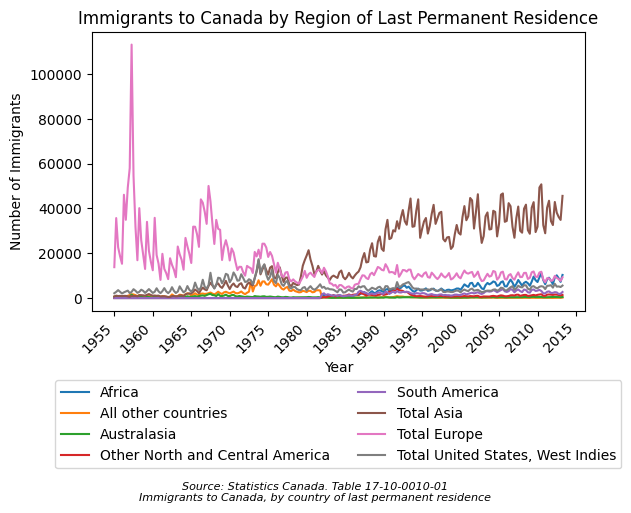

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Work on a fresh copy so the original dataframe is left untouched
df_immigrants_line = df_origin_simple_filtered_plot.copy()

# Move the index into a normal column so we can clean it
df_immigrants_line = df_immigrants_line.reset_index()

# The first column now holds the dates (and possibly a "REF_DATE" header row)
date_col = df_immigrants_line.columns[0]

# Keep only rows that look like real dates
mask = df_immigrants_line[date_col].astype(str).str.contains("-", na=False)
df_clean = df_immigrants_line.loc[mask].copy()

# Rename cleanly
df_clean = df_clean.rename(columns={date_col: "date"})
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Make sure the region columns are numeric
region_cols = [
    "Africa",
    "All other countries",
    "Australasia",
    "Other North and Central America",
    "South America",
    "Total Asia",
    "Total Europe",
    "Total United States, West Indies"
]

for col in region_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

df_clean = df_clean.sort_values("date").reset_index(drop=True)

# Plot
fig, ax = plt.subplots()

for col in region_cols:
    ax.plot(df_clean["date"], df_clean[col], linestyle="-", label=col)

ax.set_title("Immigrants to Canada by Region of Last Permanent Residence")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Immigrants")

# Show a year label roughly every 5 years so the axis is readable
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ===== easy vertical controls =====
legend_y = -0.225         # move legend up/down (more negative = lower)
source_y = -0.055         # move source up/down
bottom_margin = 0.38     # how much space to leave under the plot
# ==================================

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, legend_y),
    ncol=2,
    frameon=True
)

plt.xticks(rotation=45, ha="right")

plt.subplots_adjust(bottom=bottom_margin)

plt.figtext(
    0.5, source_y,
    "Source: Statistics Canada. Table 17-10-0010-01\nImmigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

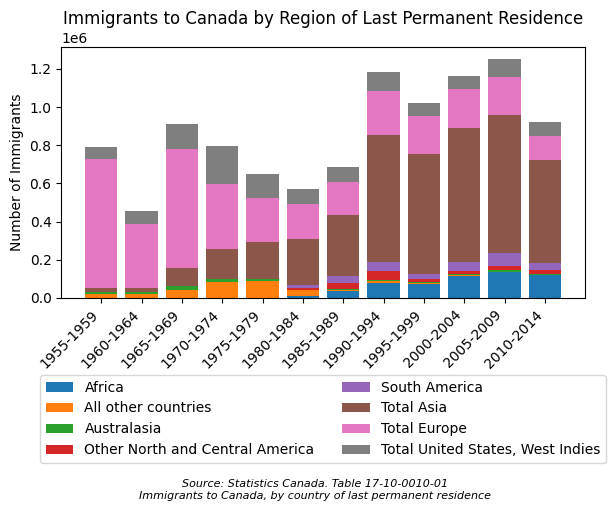

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Work on a fresh copy so the original dataframe is left untouched
df_immigrants_5yr = df_origin_simple_filtered_plot.copy()

# Move the index into a normal column so we can clean it
df_immigrants_5yr = df_immigrants_5yr.reset_index()

# The first column now holds the dates (and possibly a "REF_DATE" header row)
date_col = df_immigrants_5yr.columns[0]

# Keep only rows that look like real dates
mask = df_immigrants_5yr[date_col].astype(str).str.contains("-", na=False)
df_clean = df_immigrants_5yr.loc[mask].copy()

# Rename cleanly
df_clean = df_clean.rename(columns={date_col: "date"})
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Make sure the region columns are numeric
region_cols = [
    "Africa",
    "All other countries",
    "Australasia",
    "Other North and Central America",
    "South America",
    "Total Asia",
    "Total Europe",
    "Total United States, West Indies"
]

for col in region_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

df_clean = df_clean.sort_values("date").reset_index(drop=True)

# Aggregate by 5-year periods (sum each period; final period ends at 2013)
df_clean["year"] = df_clean["date"].dt.year
df_clean["period"] = (df_clean["year"] // 5) * 5

df_period = (
    df_clean.groupby("period")[region_cols]
    .sum()
    .reset_index()
    .sort_values("period")
)

# Period labels (e.g. 1950-1954); last partial period is fine
df_period["period_label"] = (
    df_period["period"].astype(str) + "-" + (df_period["period"] + 4).astype(str)
)

# Plot stacked bars
fig, ax = plt.subplots()

bottom = np.zeros(len(df_period))
for col in region_cols:
    ax.bar(df_period["period_label"], df_period[col], bottom=bottom, label=col)
    bottom += df_period[col].values

ax.set_title("Immigrants to Canada by Region of Last Permanent Residence")
# ax.set_xlabel("Period")
ax.set_ylabel("Number of Immigrants")

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=True
)

plt.xticks(rotation=45, ha="right")

plt.subplots_adjust(bottom=0.38)

plt.figtext(
    0.5, -0.05,
    "Source: Statistics Canada. Table 17-10-0010-01\nImmigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

In [22]:
main_regions

['Total Europe',
 'Total Asia',
 'Australasia',
 'Total United States, West Indies',
 'Africa',
 'Other North and Central America',
 'South America',
 'All other countries']

In [23]:
df_origin_simple_nations = df_origin_simple[~df_origin_simple["Last permanent residence"].isin(main_regions + ["Total immigrants"])]
df_origin_simple_nations[df_origin_simple_nations["REF_DATE"] == "1955-01"]

,REF_DATE,Last permanent residence,VALUE
2,1955-01,Great Britain,4270
3,1955-01,France,343
4,1955-01,Germany,1921
5,1955-01,Netherlands,1058
6,1955-01,Greece,521
7,1955-01,Italy,4296
8,1955-01,Portugal,21
9,1955-01,Other Europe,1345
13,1955-01,United States,2062
14,1955-01,West Indies,86


In [24]:
df_origin_simple_nations

,REF_DATE,Last permanent residence,VALUE
2,1955-01,Great Britain,4270
3,1955-01,France,343
4,1955-01,Germany,1921
5,1955-01,Netherlands,1058
6,1955-01,Greece,521
...,...,...,...
4867,2013-04,Vietnam,510
4868,2013-04,Philippines,8428
4869,2013-04,Other Asia,25818
4872,2013-04,United States,2663


In [25]:
set(df_origin_simple_nations["Last permanent residence"].values.tolist())


{'France',
 'Germany',
 'Great Britain',
 'Greece',
 'Hong Kong',
 'India',
 'Italy',
 'Netherlands',
 'Other Asia',
 'Other Europe',
 'Philippines',
 'Poland',
 'Portugal',
 'United States',
 'Vietnam',
 'West Indies'}

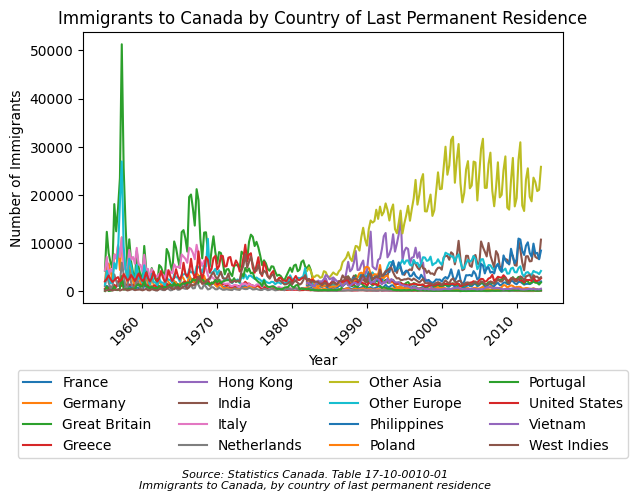

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_origin_simple_nations.copy()
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])

df_pivot = df.pivot(
    index="REF_DATE",
    columns="Last permanent residence",
    values="VALUE"
)

fig, ax = plt.subplots()

for country in df_pivot.columns:
    ax.plot(
        df_pivot.index,
        df_pivot[country],
        linestyle="-",
        label=country
    )

ax.set_title("Immigrants to Canada by Country of Last Permanent Residence")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Immigrants")

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    frameon=True
)

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 17-10-0010-01\nImmigrants to Canada, by country of last permanent residence",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()